Gender counts:
bio_sex
male       976
female     239
unknown     44
Name: count, dtype: int64

Timestamp Übersicht:
0   2014-08-27 11:29:31
1   2014-08-27 11:29:37
2   2014-08-27 11:29:44
3   2014-08-27 11:29:46
4   2014-08-27 11:30:22
Name: Timestamp, dtype: datetime64[us]

Datentypen nach Bereinigung:
Timestamp                    datetime64[us]
Age                                   int64
Gender                                  str
Country                                 str
state                                   str
self_employed                           str
family_history                          str
treatment                               str
work_interfere                          str
no_employees                            str
remote_work                             str
tech_company                            str
benefits                                str
care_options                            str
wellness_program                        str
seek_help                          

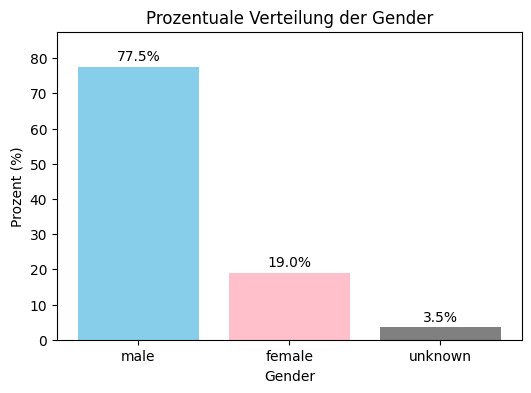

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("survey.csv")

# --- Gender bereinigen ---
male_variants = {"male", "m", "mal", "maile"}
female_variants = {"female", "f", "femal", "femail"}

def map_bio_sex_robust(value):
    if pd.isna(value):
        return "unknown"
    v = str(value).strip().lower()
    if v in male_variants:
        return "male"
    if v in female_variants:
        return "female"
    return "unknown"

df["bio_sex"] = df["Gender"].apply(map_bio_sex_robust)

# --- Timestamp bereinigen ---
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# --- Optionale Kontrolle ---
print("Gender counts:")
print(df["bio_sex"].value_counts(dropna=False))

print("\nTimestamp Übersicht:")
print(df["Timestamp"].head())

print("\nDatentypen nach Bereinigung:")
print(df.dtypes)

# --- Balkendiagramm mit Prozentangaben ---
gender_counts = df["bio_sex"].value_counts()
gender_percent = gender_counts / gender_counts.sum() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(gender_percent.index, gender_percent.values, color=["skyblue", "pink", "gray"])

plt.title("Prozentuale Verteilung der Gender")
plt.xlabel("Gender")
plt.ylabel("Prozent (%)")

# Prozentwerte über den Balken anzeigen
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%", ha='center', va='bottom')

plt.ylim(0, max(gender_percent.values) + 10)
plt.show()